# Modelo Preditivo

A estrutura será:

Criar a variável alvo: target_detrator.

Separar variáveis de entrada.

Separar treino e teste.

Criar pipeline com tratamento de variáveis numéricas e categóricas.

Treinar um modelo base.

Comparar com modelos melhores.

Avaliar com métricas de negócio.

Interpretar fatores mais importantes.

Criar uma lista de clientes em risco.

In [20]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt


warnings.filterwarnings('ignore')

In [5]:

df_model = df = pd.read_csv("..\\data\\processed\\desafio_nps_fase_1_processado.csv")

df_model["target_detrator"] = np.where(df_model["nps_score"] < 7, 1, 0)

print("Distribuição da variável alvo:")
display(
    df_model["target_detrator"]
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={0: "Não detrator", 1: "Detrator"})
)

Distribuição da variável alvo:


target_detrator
Detrator        84.36
Não detrator    15.64
Name: proportion, dtype: float64

## Definição da variável alvo:

A variável target_detrator indica se o cliente provavelmente será um detrator.

Regra:
- nps_score <= 6: Detrator
- nps_score > 6: Não detrator

Essa abordagem é útil para o negócio porque permite priorizar ações preventivas.
Em vez de tentar prever uma nota exata, o modelo identifica clientes com risco de insatisfação.

In [6]:

features_modelo = [
    "customer_age",
    "customer_region",
    "customer_tenure_months",
    "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",
    "delivery_time_days",
    "delivery_delay_days",
    "freight_value",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count"
]

X = df_model[features_modelo]
y = df_model["target_detrator"]

print("Variáveis usadas no modelo:")
print(features_modelo)

print("\nTamanho de X:")
print(X.shape)

print("\nTamanho de y:")
print(y.shape)

Variáveis usadas no modelo:
['customer_age', 'customer_region', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count']

Tamanho de X:
(2500, 14)

Tamanho de y:
(2500,)


## Critério de seleção das variáveis:

Foram usadas variáveis conhecidas durante ou ao final da jornada operacional,
mas antes da resposta da pesquisa de NPS.

Não usamos:
- nps_score, porque é a própria resposta que queremos prever;
- nps_category, porque foi derivada do NPS;
- customer_id e order_id, porque são identificadores;
- repeat_purchase_30d, porque pode acontecer depois do NPS;
- csat_internal_score, porque pode representar vazamento caso seja medido depois da experiência.

Essa escolha torna o modelo mais realista para uso preventivo.

In [ ]:
# Split dos dados em treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:")
print(X_train.shape)

print("\nTeste:")
print(X_test.shape)

print("\nDistribuição da target no treino:")
print(y_train.value_counts(normalize=True).mul(100))

print("\nDistribuição da target no teste:")
print(y_test.value_counts(normalize=True).mul(100))

Treino:
(1875, 14)

Teste:
(625, 14)

Distribuição da target no treino:
target_detrator
1    84.373333
0    15.626667
Name: proportion, dtype: float64

Distribuição da target no teste:
target_detrator
1    84.32
0    15.68
Name: proportion, dtype: float64


In [8]:
# Pré-processamento dos dados
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

colunas_categoricas = ["customer_region"]

colunas_numericas = [
    col for col in features_modelo
    if col not in colunas_categoricas
]

preprocessamento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas)
    ]
)

print("Colunas numéricas:")
print(colunas_numericas)

print("\nColunas categóricas:")
print(colunas_categoricas)

Colunas numéricas:
['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count']

Colunas categóricas:
['customer_region']


In [10]:

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

baseline = DummyClassifier(strategy="most_frequent")

pipeline_baseline = Pipeline(
    steps=[
        ("preprocessamento", preprocessamento),
        ("modelo", baseline)
    ]
)

pipeline_baseline.fit(X_train, y_train)

y_pred_baseline = pipeline_baseline.predict(X_test)

print("Baseline - sempre prevê a classe mais frequente")
print(classification_report(y_test, y_pred_baseline))

Baseline - sempre prevê a classe mais frequente
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        98
           1       0.84      1.00      0.91       527

    accuracy                           0.84       625
   macro avg       0.42      0.50      0.46       625
weighted avg       0.71      0.84      0.77       625



## Por que criar um baseline?

Porque a base tem muitos detratores.
Se o modelo simplesmente prever que todo mundo é detrator,
ele pode ter uma acurácia aparentemente alta.

Por isso, não podemos avaliar apenas por acurácia.
Precisamos olhar principalmente:
- recall da classe detrator;
- precision da classe detrator;
- F1-score;
- matriz de confusão;
- ROC AUC.

Para o negócio, recall é importante porque queremos capturar o máximo possível de clientes em risco.

In [11]:
# Modelo de Regressão Logística
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

pipeline_logistico = Pipeline(
    steps=[
        ("preprocessamento", preprocessamento),
        ("modelo", modelo_logistico)
    ]
)

pipeline_logistico.fit(X_train, y_train)

y_pred_logistico = pipeline_logistico.predict(X_test)
y_proba_logistico = pipeline_logistico.predict_proba(X_test)[:, 1]

print("Regressão Logística")
print(classification_report(y_test, y_pred_logistico))

print("ROC AUC:", roc_auc_score(y_test, y_proba_logistico))

Regressão Logística
              precision    recall  f1-score   support

           0       0.43      0.76      0.55        98
           1       0.95      0.82      0.88       527

    accuracy                           0.81       625
   macro avg       0.69      0.79      0.71       625
weighted avg       0.87      0.81      0.83       625

ROC AUC: 0.8850249777330287


In [12]:
# Modelo de Random Forest
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

pipeline_rf = Pipeline(
    steps=[
        ("preprocessamento", preprocessamento),
        ("modelo", modelo_rf)
    ]
)

pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.46      0.76      0.57        98
           1       0.95      0.84      0.89       527

    accuracy                           0.82       625
   macro avg       0.71      0.80      0.73       625
weighted avg       0.87      0.82      0.84       625

ROC AUC: 0.8867869728536576


In [13]:
# Modelo de Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

modelo_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

pipeline_gb = Pipeline(
    steps=[
        ("preprocessamento", preprocessamento),
        ("modelo", modelo_gb)
    ]
)

pipeline_gb.fit(X_train, y_train)

y_pred_gb = pipeline_gb.predict(X_test)
y_proba_gb = pipeline_gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))

print("ROC AUC:", roc_auc_score(y_test, y_proba_gb))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.66      0.40      0.50        98
           1       0.90      0.96      0.93       527

    accuracy                           0.87       625
   macro avg       0.78      0.68      0.71       625
weighted avg       0.86      0.87      0.86       625

ROC AUC: 0.8868063354374007


In [ ]:

def avaliar_modelo(nome, y_true, y_pred, y_proba):
    """
    Avalia um modelo de machine learning com base em várias métricas.
    Args:
        nome (str): Nome do modelo.
        y_true (array-like): Valores reais da variável alvo.
        y_pred (array-like): Valores previstos pelo modelo.
        y_proba (array-like): Probabilidades previstas pelo modelo. 
    returns:
        dict: Um dicionário contendo o nome do modelo e várias métricas de avaliação, incluindo acurácia, precisão, recall, F1-score e AUC-ROC.
    """
    return {
        "modelo": nome,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_detrator": precision_score(y_true, y_pred, pos_label=1),
        "recall_detrator": recall_score(y_true, y_pred, pos_label=1),
        "f1_detrator": f1_score(y_true, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }

resultados_modelos = pd.DataFrame([
    avaliar_modelo("Regressão Logística", y_test, y_pred_logistico, y_proba_logistico),
    avaliar_modelo("Random Forest", y_test, y_pred_rf, y_proba_rf),
    avaliar_modelo("Gradient Boosting", y_test, y_pred_gb, y_proba_gb)
])

display(resultados_modelos.sort_values("roc_auc", ascending=False))

,modelo,accuracy,precision_detrator,recall_detrator,f1_detrator,roc_auc
2,Gradient Boosting,0.8736,0.895760,0.962049,0.927722,0.886806
1,Random Forest,0.8240,0.948387,0.836812,0.889113,0.886787
0,Regressão Logística,0.8064,0.947137,0.815939,0.876656,0.885025


In [ ]:
# Selecionando o melhor modelo com base na métrica ROC AUC
melhor_modelo = pipeline_gb
y_pred_melhor = y_pred_gb
y_proba_melhor = y_proba_gb

matriz = confusion_matrix(y_test, y_pred_melhor)

matriz_confusao = pd.DataFrame(
    matriz,
    index=["Real não detrator", "Real detrator"],
    columns=["Previsto não detrator", "Previsto detrator"]
)

display(matriz_confusao)

,Previsto não detrator,Previsto detrator
Real não detrator,39,59
Real detrator,20,507


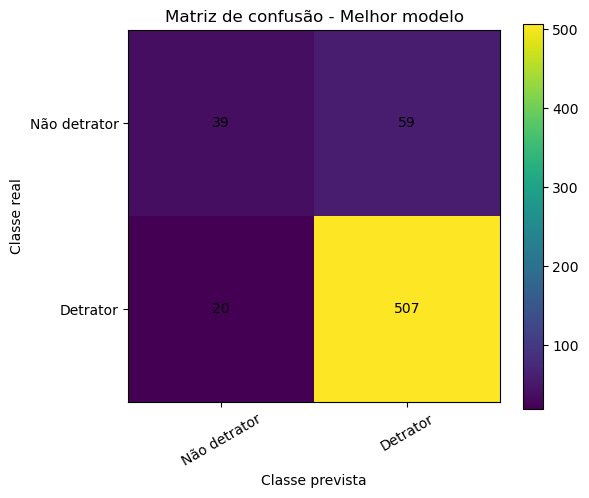

In [21]:

plt.figure(figsize=(6, 5))
plt.imshow(matriz, interpolation="nearest")
plt.title("Matriz de confusão - Melhor modelo")
plt.colorbar()

classes = ["Não detrator", "Detrator"]
plt.xticks(np.arange(len(classes)), classes, rotation=30)
plt.yticks(np.arange(len(classes)), classes)

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        plt.text(j, i, matriz[i, j], ha="center", va="center")

plt.ylabel("Classe real")
plt.xlabel("Classe prevista")
plt.show()

## Como ler a matriz de confusão:

1. Real detrator e previsto detrator:
Clientes em risco que o modelo conseguiu identificar corretamente.

2. Real detrator e previsto não detrator:
Clientes insatisfeitos que o modelo deixou passar.
Esse é o erro mais perigoso para o negócio.

3. Real não detrator e previsto detrator:
Clientes que seriam acionados sem necessidade.
Esse erro gera custo operacional, mas pode ser aceitável se a ação preventiva for barata.

4. Real não detrator e previsto não detrator:
Clientes sem risco que o modelo classificou corretamente.

Como o objetivo é prevenção, normalmente aceitamos alguns falsos positivos
para reduzir falsos negativos.

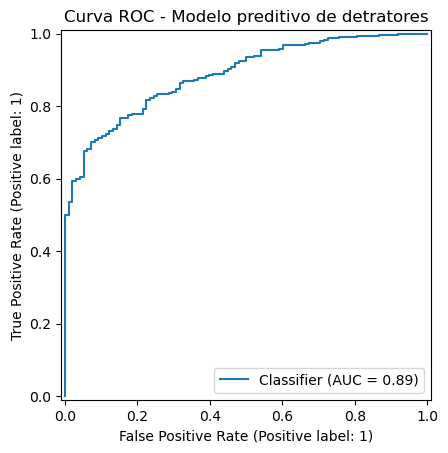

In [23]:

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba_melhor)
plt.title("Curva ROC - Modelo preditivo de detratores")
plt.show()

In [ ]:
#  Avaliação dos modelos com diferentes thresholds
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

avaliacao_thresholds = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_melhor >= threshold).astype(int)

    avaliacao_thresholds.append({
        "threshold": threshold,
        "precision_detrator": precision_score(y_test, y_pred_threshold, pos_label=1),
        "recall_detrator": recall_score(y_test, y_pred_threshold, pos_label=1),
        "f1_detrator": f1_score(y_test, y_pred_threshold, pos_label=1),
        "clientes_classificados_como_risco": y_pred_threshold.sum()
    })

avaliacao_thresholds = pd.DataFrame(avaliacao_thresholds)

display(avaliacao_thresholds)

,threshold,precision_detrator,recall_detrator,f1_detrator,clientes_classificados_como_risco
0,0.3,0.879865,0.986717,0.930233,591
1,0.4,0.881647,0.975332,0.926126,583
2,0.5,0.895760,0.962049,0.927722,566
3,0.6,0.903636,0.943074,0.922934,550
4,0.7,0.912381,0.908918,0.910646,525


## O threshold define o nível de sensibilidade do modelo.

Threshold menor, como 0.30:
- O modelo identifica mais clientes em risco;
- Aumenta o recall;
- Mas também pode gerar mais falsos positivos.

Threshold maior, como 0.70:
- O modelo fica mais conservador;
- Aciona menos clientes;
- Mas pode deixar detratores reais passarem.

Para o negócio, a escolha depende do custo da ação preventiva.
Se mandar uma mensagem ou priorizar atendimento for barato, podemos usar threshold menor.
Se oferecer cupom ou compensação for caro, podemos usar threshold maior.

In [26]:
# Ranking dos clientes com maior risco de serem detratores
df_teste_resultado = X_test.copy()
df_teste_resultado["target_real_detrator"] = y_test.values
df_teste_resultado["probabilidade_detrator"] = y_proba_melhor

df_teste_resultado["classificacao_risco"] = pd.cut(
    df_teste_resultado["probabilidade_detrator"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=["Baixo risco", "Médio risco", "Alto risco", "Risco crítico"],
    include_lowest=True
)

ranking_clientes_risco = df_teste_resultado.sort_values(
    "probabilidade_detrator",
    ascending=False
)

display(ranking_clientes_risco.head(20))

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,target_real_detrator,probabilidade_detrator,classificacao_risco
766,46,Norte,84,139.76,5,9.24,11,6,5,45.37,2,4,10,8,1,0.997770,Risco crítico
1993,19,Sul,76,489.59,6,39.27,8,8,4,53.25,1,3,10,6,1,0.997602,Risco crítico
1997,50,Centro-Oeste,34,1126.92,6,48.74,8,4,3,43.70,2,2,9,7,1,0.997473,Risco crítico
328,48,Centro-Oeste,31,294.92,4,5.70,11,12,6,51.43,1,4,6,9,1,0.997172,Risco crítico
119,19,Sudeste,85,428.10,4,77.12,5,6,3,47.30,3,2,9,6,1,0.997145,Risco crítico
664,49,Centro-Oeste,116,626.83,3,15.11,10,9,5,50.74,2,2,10,7,1,0.997110,Risco crítico
1529,44,Sudeste,80,404.40,2,12.49,10,5,5,25.46,2,1,10,4,1,0.996964,Risco crítico
768,45,Norte,75,482.15,2,37.46,4,12,5,21.47,2,4,6,7,1,0.996727,Risco crítico
674,59,Sul,78,288.59,6,59.46,7,7,4,35.22,2,2,5,6,1,0.996444,Risco crítico
156,54,Sudeste,34,348.10,1,26.64,5,4,4,31.63,2,2,10,6,1,0.996292,Risco crítico


In [27]:

resumo_faixa_risco = (
    ranking_clientes_risco
    .groupby("classificacao_risco")
    .agg(
        clientes=("probabilidade_detrator", "count"),
        probabilidade_media_detrator=("probabilidade_detrator", "mean"),
        percentual_detratores_reais=("target_real_detrator", lambda x: x.mean() * 100),
        atraso_medio=("delivery_delay_days", "mean"),
        reclamacoes_medias=("complaints_count", "mean"),
        contatos_medios=("customer_service_contacts", "mean"),
        tempo_resolucao_medio=("resolution_time_days", "mean")
    )
    .reset_index()
)

display(resumo_faixa_risco)

,classificacao_risco,clientes,probabilidade_media_detrator,percentual_detratores_reais,atraso_medio,reclamacoes_medias,contatos_medios,tempo_resolucao_medio
0,Baixo risco,34,0.194609,20.588235,0.323529,1.352941,0.705882,3.588235
1,Médio risco,41,0.475076,56.097561,0.829268,2.365854,0.829268,4.219512
2,Alto risco,59,0.715740,66.101695,1.118644,2.983051,1.152542,5.457627
3,Risco crítico,491,0.949571,93.279022,2.541752,4.613035,1.690428,5.672098


## As faixas de risco transformam o modelo em uma ferramenta de gestão.

Exemplo de uso:

Baixo risco:
- Monitoramento normal.

Médio risco:
- Comunicação preventiva automática.

Alto risco:
- Prioridade no atendimento.

Risco crítico:
- Ação humana imediata, priorização logística ou política de compensação.

Essa abordagem facilita a adoção do modelo pelas áreas de logística,
atendimento e experiência do cliente.

In [28]:
# Recuperar nomes das variáveis após o OneHotEncoder
nomes_num = colunas_numericas

encoder = pipeline_rf.named_steps["preprocessamento"].named_transformers_["cat"]
nomes_cat = encoder.get_feature_names_out(colunas_categoricas).tolist()

nomes_features_processadas = nomes_num + nomes_cat

importancias_rf = pipeline_rf.named_steps["modelo"].feature_importances_

df_importancias_rf = pd.DataFrame({
    "variavel": nomes_features_processadas,
    "importancia": importancias_rf
}).sort_values("importancia", ascending=False)

display(df_importancias_rf.head(15))

,variavel,importancia
7,delivery_delay_days,0.383053
12,complaints_count,0.304726
10,customer_service_contacts,0.083608
11,resolution_time_days,0.073158
2,order_value,0.028017
4,discount_value,0.026310
8,freight_value,0.021195
0,customer_age,0.020400
1,customer_tenure_months,0.015233
6,delivery_time_days,0.012183


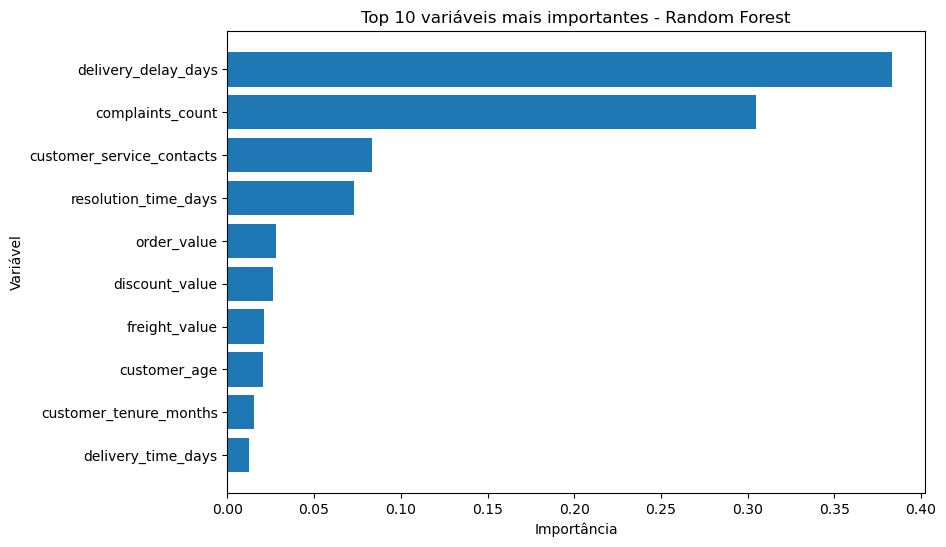

In [29]:

top_importancias = df_importancias_rf.head(10).sort_values("importancia")

plt.figure(figsize=(9, 6))
plt.barh(top_importancias["variavel"], top_importancias["importancia"])
plt.title("Top 10 variáveis mais importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

## A importância das variáveis ajuda a explicar o modelo para o negócio.

Se atraso, reclamações, contatos com atendimento e tempo de resolução
aparecem entre as variáveis mais importantes, o modelo confirma a EDA.

Isso fortalece a narrativa:
o risco de detrator é explicado principalmente por falhas operacionais na jornada,
não apenas pelo perfil do cliente.

In [30]:
# Modelo com CSAT interno
features_com_csat = features_modelo + ["csat_internal_score"]

X_csat = df_model[features_com_csat]
y_csat = df_model["target_detrator"]

X_train_csat, X_test_csat, y_train_csat, y_test_csat = train_test_split(
    X_csat,
    y_csat,
    test_size=0.25,
    random_state=42,
    stratify=y_csat
)

colunas_categoricas_csat = ["customer_region"]
colunas_numericas_csat = [
    col for col in features_com_csat
    if col not in colunas_categoricas_csat
]

preprocessamento_csat = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas_csat),
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas_csat)
    ]
)

modelo_rf_csat = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

pipeline_rf_csat = Pipeline(
    steps=[
        ("preprocessamento", preprocessamento_csat),
        ("modelo", modelo_rf_csat)
    ]
)

pipeline_rf_csat.fit(X_train_csat, y_train_csat)

y_pred_csat = pipeline_rf_csat.predict(X_test_csat)
y_proba_csat = pipeline_rf_csat.predict_proba(X_test_csat)[:, 1]

print("Modelo com CSAT interno")
print(classification_report(y_test_csat, y_pred_csat))
print("ROC AUC:", roc_auc_score(y_test_csat, y_proba_csat))

Modelo com CSAT interno
              precision    recall  f1-score   support

           0       0.42      0.74      0.54        98
           1       0.94      0.81      0.87       527

    accuracy                           0.80       625
   macro avg       0.68      0.78      0.71       625
weighted avg       0.86      0.80      0.82       625

ROC AUC: 0.8855671300778375


In [31]:

comparacao_csat = pd.DataFrame([
    avaliar_modelo("Sem CSAT", y_test, y_pred_rf, y_proba_rf),
    avaliar_modelo("Com CSAT", y_test_csat, y_pred_csat, y_proba_csat)
])

display(comparacao_csat)

,modelo,accuracy,precision_detrator,recall_detrator,f1_detrator,roc_auc
0,Sem CSAT,0.8240,0.948387,0.836812,0.889113,0.886787
1,Com CSAT,0.8016,0.944812,0.812144,0.873469,0.885567


## O modelo com CSAT pode ter desempenho melhor,
mas precisamos ter cuidado com vazamento de dados.

Se o CSAT for coletado antes do NPS, ele pode ser usado.
Se for coletado depois ou junto com a pesquisa de satisfação,
ele não deve ser usado no modelo preventivo.

Por isso, a versão principal do modelo deve ser a versão sem CSAT.
A versão com CSAT pode ser apresentada como análise complementar.

In [32]:

import joblib

joblib.dump(melhor_modelo, "..\\models\\modelo_predicao_detrator_nps.pkl")

print("Modelo salvo como modelo_predicao_detrator_nps.pkl")

Modelo salvo como modelo_predicao_detrator_nps.pkl


## Metodologia

Foi adotado um modelo de classificação para prever se um cliente possui risco de se tornar detrator. A variável alvo foi criada a partir do nps_score, considerando detratores os clientes com nota menor ou igual a 6. Essa estratégia foi escolhida porque facilita a tomada de decisão: em vez de estimar uma nota exata, o modelo gera uma probabilidade de risco, permitindo que áreas como atendimento e logística priorizem clientes mais vulneráveis.

## Justificativa

O modelo pode ser usado para criar uma fila de priorização operacional. Clientes com alta probabilidade de detrator podem receber contato proativo, acompanhamento logístico, atendimento prioritário ou ações de recuperação de experiência antes da resposta da pesquisa de NPS.

## Recomendação

A análise exploratória mostrou que atraso, reclamações e esforço no atendimento estão fortemente associados à queda no NPS. O modelo preditivo transforma esses sinais em uma probabilidade de risco, permitindo que a empresa deixe de reagir ao NPS depois da pesquisa e passe a agir preventivamente durante a jornada do cliente.